## **Sección 1**: *Simulated Annealing* (Recocido Simulado)

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from auxiliar_eduardito import *
from IPython.display import clear_output
import time
import pandas as pd


### 1.1 Implementación del algoritmo

> Implemente el algoritmo de **Simulated Annealing (Recocido Simulado)** empleando el **schedule geométrico** como esquema para controlar la evolución de la temperatura $T$ a lo largo de las iteraciones. Emplee como criterio de parada un número máximo de iteraciones $N_{\text{max}}$, y considere además los siguientes criterios complementarios:
> - **Temperatura mínima**: detener cuando $T < T_{\text{min}}$ (ej: $T_{\text{min}} = 10^{-3}$)
> - **Estancamiento**: detener si no hay mejora en el mejor fitness durante $k$ iteraciones consecutivas
> - **Número de evaluaciones**: detener después de un número fijo de evaluaciones de la función objetivo (relevante para la comparación solicitada en la Sección 3)
> Puede encontrar más detalles del algoritmo en el **Anexo I**.


In [95]:
class simulated_annealing():
    def __init__(self, function, start_point, lower, upper, T_0, alfa, sigma, cold_function, n_max=1000, variables = ['x'], minimize=True):
        #parametros del problema
        self.function = function
        self.start_point = np.array(start_point, dtype=float)
        self.lower = np.array(lower)
        self.upper = np.array(upper)
        self.variables = variables
        self.minimize = minimize

        #parametros del algoritmo
        self.T_0 = T_0
        self.alfa = alfa
        self.sigma = sigma
        self.cold_function = cold_function
        self.n_max = n_max


        #historiales para graaficos
        self.hist_t = []
        self.hist_fitness = []
        self.hist_points = []

        #resutlados para el analisis
        self.best_point = None
        self.best_fitness = None
        self.t_best = None
        self.accepted = {
            'total': 1,
            'worse': 0
        }
        
        
    def is_better_point(self,delta_f):
        if self.minimize:
            return delta_f<0
        else:
            return delta_f>0
        
    def fitness_improved(self,f_current):
        if self.minimize:
            return f_current < self.best_fitness
        else:
            return f_current > self.best_fitness

    def run(self):
        curr_point = self.start_point.copy()
        f_curr = self.function(curr_point)

        self.best_point = curr_point.copy() #por ahora el mejor putno es el inicial
        self.best_fitness = f_curr

        T = self.T_0
        self.t_best = 1
        for t in range(1,self.n_max): #itero
            point_p = np.random.normal(curr_point, self.sigma) #genero punto vecino
            point_p = np.clip(point_p, self.lower, self.upper)

            f_p = self.function(point_p) #evaluo el fitnes vecino
            delta_f = f_p - f_curr

            #criterio de aceptacion
            if self.is_better_point(delta_f): #mejora, acepto siempore
                curr_point = point_p.copy()
                f_curr = f_p
                self.accepted['total']+=1
                
            else: #empeora, salto con una probabilidad
                prob = np.exp(-abs(delta_f) / T)
                r = np.random.uniform(0,1)
                if r<prob: #acepto el salto
                    curr_point = point_p.copy()
                    f_curr = f_p
                    self.accepted['total']+=1
                    self.accepted['worse']+=1

            if self.fitness_improved(f_curr): #actualizo
                self.best_point = curr_point.copy()
                self.best_fitness = f_curr
                self.t_best = t
            
            self.hist_t.append(t)
            self.hist_fitness.append(f_curr)
            self.hist_points.append(curr_point.copy())

            T= self.cold_function(self.alfa, self.T_0, t)
        return self.best_point, self.best_fitness # tupla(x,y)
    
def geometric_cooling(alfa, T_0, t):
    return (alfa**t) *T_0

def logarithmic_cooling(alfa, T_0, t):
    return T_0 /np.log(1+t)   

def exponential_cooling(alfa, T_0,t):
    return T_0*np.exp(-alfa*t)        
        

In [96]:
def animate_annealing_1d(sa_model, function, lower, upper, var_name="x", sleep=0.001):
    
    dom = np.linspace(lower, upper, 1000)
    y = function(dom)
    
    y_min = min(sa_model.hist_fitness)
    y_max = max(sa_model.hist_fitness)
    
    pts = np.array(sa_model.hist_points)
    
    for i in range(len(sa_model.hist_t)):
        clear_output(wait=True)
        
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        
        axs[0].plot(dom, y, color='black', alpha=0.3)
   
        xs = pts[:i, 0] 
  
        ys = sa_model.hist_fitness[:i]
        
        axs[0].scatter(xs, ys, s=10, alpha=0.5)
        
        if i > 0:
            axs[0].scatter(xs[-1], ys[-1], color='red', label='actual')
        
        axs[0].set_xlim(lower, upper)
        axs[0].set_xlabel(var_name)
        axs[0].set_ylabel("f(x)")
        axs[0].set_title(f"Exploración - Iteración {i}")
        
        axs[1].plot(sa_model.hist_t[:i], sa_model.hist_fitness[:i])
        axs[1].set_xlim(0, sa_model.n_max)
        axs[1].set_ylim(y_min, y_max)
        
        axs[1].set_xlabel("t")
        axs[1].set_ylabel("fitness")
        axs[1].set_title("Evolución del fitness")
        
        plt.tight_layout()
        plt.show()
        
        time.sleep(sleep)

> Analice el funcionamiento del algoritmo durante la minimización de la función $f_1(x)$ de Schwefel, empleando los siguientes parámetros iniciales: $T_0 = 100$, $\alpha = 0.95$, $N_{\text{max}} = 1000$, inicialización aleatoria en $[-512, 512]$. Ejecute el algoritmo varias veces y realice las siguientes actividades: (1) grafique la evolución del fitness y determine si presenta oscilaciones, y si disminuyen con el descenso de la temperatura, (2) si el algoritmo logra escapar de óptimos locales en etapas tempranas de la exploración, (3) en qué momento de la ejecución típicamente se encuentra la mejor solución. Experimente modificando $T_0$ y $\alpha$ para desarrollar intuición sobre su efecto en el comportamiento del algoritmo.


In [97]:
np.random.seed(30)
T_0 = 100
alfa = 0.95
n_max = 200
sigma = 50
lower_limit = [-512]
upper_limit = [512]

start_point = np.array([np.random.uniform(lower_limit[0], upper_limit[0])])

sa = simulated_annealing(
    function=f_1, 
    start_point=start_point, 
    lower=lower_limit, 
    upper=upper_limit, 
    T_0=T_0, 
    alfa=alfa, 
    sigma=sigma, 
    cold_function=geometric_cooling, 
    n_max=n_max
)
best_point, f_best = sa.run()

print(best_point, f_best)
# animate_annealing_1d(
#     sa,
#     f_1,
#     lower=-512,
#     upper=512,
#     var_name="x",
#     sleep=0.0001
# )

[203.99275736] [-201.83915674]


In [98]:
# esto lo usamos???
def simulated_annealing_live(start_point, function, lower, upper, T_0, alfa, sigma, enfriamiento, n_max=1000):
    
    curr_point = start_point.copy()
    f_curr = function(curr_point).item()
    
    f_best = f_curr
    best_point = curr_point.copy()
    T = T_0
    
    hist_t = []
    hist_f = []
    hist_x = []
    
    # dominio para graficar f(x)
    dom = np.linspace(lower[0], upper[0], 1000)
    y = function(dom)
    
    for t in range(n_max):
        
        # propuesta
        x_p = np.clip(np.random.normal(curr_point[0], sigma), lower[0], upper[0])
        x_p = np.array([x_p])
        
        f_p = function(x_p).item()
        delta_f = f_p - f_curr
        
        # aceptación
        if delta_f < 0:
            curr_point = x_p.copy()
            f_curr = f_p
        else:
            arg = np.clip(-delta_f / T, -700, 700)
            if np.random.rand() < np.exp(arg):
                curr_point = x_p.copy()
                f_curr = f_p
        
        # mejor
        if f_curr > f_best:
            best_point = curr_point.copy()
            f_best = f_curr
        
        # guardar historial
        hist_t.append(t)
        hist_f.append(f_curr)
        hist_x.append(curr_point[0])
        
        # 🔥 PLOT EN TIEMPO REAL
        clear_output(wait=True)
        
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        
        # --- izquierda: función + puntos ---
        axs[0].plot(dom, y)
        axs[0].scatter(hist_x, [function(np.array([x])).item() for x in hist_x], s=10)
        axs[0].scatter(curr_point[0], f_curr, color='red', label='actual')
        axs[0].set_title("Exploración")
        axs[0].set_xlabel("x")
        axs[0].set_ylabel("f(x)")
        axs[0].legend()
        
        # --- derecha: fitness ---
        axs[1].plot(hist_t, hist_f)
        axs[1].set_title("Evolución del fitness")
        axs[1].set_xlabel("t")
        axs[1].set_ylabel("fitness")
        
        plt.tight_layout()
        plt.show()
        
        # enfriamiento
        T = enfriamiento(alfa, T_0, t)
    
    return best_point, f_best

### 1.2 Análisis de hiperparámetros en Schwefel 1D

Los dos hiperparámetros fundamentales de *Simulated Annealing* con schedule geométrico son la temperatura inicial $T_0$ y la tasa de enfriamiento $\alpha$. Estos parámetros controlan el balance entre exploración y explotación a lo largo de la ejecución del algoritmo. Una calibración sistemática de estos hiperparámetros es esencial para maximizar el rendimiento del algoritmo en problemas específicos.


#### Experimento 1: Temperatura inicial

> Evalúe el efecto del valor de la temperatura inicial sobre la capacidad del algoritmo para encontrar el óptimo global de la función de Schwefel, manteniendo constante la tasa de enfriamiento.



**Configuración experimental**:

$$
\begin{aligned}
\text{Función:} & \quad f_1(x) = -x \cdot \sin(\sqrt{|x|}), \quad x \in [-512, 512] \\
\text{Hiperparámetros:} & \quad T_0 \in \{10, 50, 100, 500, 1000\} \\
& \quad \alpha = 0.95 \text{ (fijo)} \\
\text{Iteraciones:} & \quad N_{\text{max}} = 1000 \\
\text{Repeticiones:} & \quad 10 \text{ ejecuciones independientes por cada } T_0 \\
\text{Inicialización:} & \quad \text{Aleatoria uniforme en } [-512, 512] \\
\text{Vecindario:} & \quad x' = x + \mathcal{N}(0, \sigma^2), \quad \sigma = 50
\end{aligned}
$$


In [99]:
function = f_1

T_0s = [10,50,100,500,1000]
alpha = 0.95
N_max = 1000
n_exp = 50

lower = -512
upper = 512

sigma = 50

> Para cada una de las 10 repeticiones de cada valor de $T_0$, se registran las siguientes métricas:
> - **Mejor fitness alcanzado**: $f(x_{\text{best}})$
> - **Posición de la mejor solución**: $x_{\text{best}}$
> - **Iteración en que se encontró**: $t_{\text{best}}$
> - **Número de aceptaciones de movimientos que empeoran**: para calcular tasa de aceptación
> Para cada valor de $T_0 \in \{10, 50, 100, 500, 1000\}$, calcular sobre las 10 repeticiones:
> 1. **Media aritmética** del mejor fitness: $\bar{f} = \frac{1}{10}\sum_{i=1}^{10} f_i$
> 2. **Desviación estándar**: $s = \sqrt{\frac{1}{9}\sum_{i=1}^{10}(f_i - \bar{f})^2}$, que cuantifica la variabilidad del algoritmo
> 3. **Mediana**: valor central que divide la distribución en dos mitades iguales, más robusta que la media ante outliers
> 4. **Valores extremos**: mínimo y máximo observados en las 10 repeticiones
> Organizar estos resultados en una tabla comparativa. Adicionalmente, genere un boxplot por cada valor de $T_0$ mostrando la distribución de los mejores fitness alcanzados.

| $T_0$ | Media | Mediana | Mín | Máx | Std |
|:-----:|:-----:|:-------:|:---:|:---:|:---:|
| 10    | ...   | ...     | ... | ... | ... |
| 50    | ...   | ...     | ... | ... | ... |
| ...   | ...   | ...     | ... | ... | ... |



**Preguntas de análisis**:

1. ¿Qué valor de $T_0$ produce el mejor rendimiento promedio? ¿Es el mismo que produce el mejor resultado individual (mínimo absoluto)?

2. ¿Cómo afecta $T_0$ a la variabilidad de los resultados (desviación estándar)? ¿Configuraciones con $T_0$ alto son más o menos consistentes?

3. ¿Temperaturas muy altas ($T_0 = 1000$) mejoran o perjudican el rendimiento? ¿Por qué?

4. ¿Cuántas de las 10 repeticiones de cada configuración logran encontrar el óptimo global (dentro de un $\varepsilon = 5$ de tolerancia)?


La estructura que van a tener los resultados son:

{10:
    {
        'best_fitness': [1, 2, ..., n],
        'X_best_fitness': [1, 2, ..., n],
        'Iteracion_encontrada' : [1,2, ..., n],
        'Aceptaciones' : [1, 2, ...., n]
    },
50:{
    'best_fitness': [1, 2, ..., n],
    ...
    }
}

In [100]:
np.random.seed(42)
results = {}

for T_0 in T_0s:
    curr_dict = {} #diccionario auxiliar
    best_x=[]
    best_fit=[]
    best_iters =[]
    accepted = []
    for i in range(n_exp):
        start_point = np.array([np.random.uniform(lower, upper)]) #puntoa aleatorio
        sa_model = simulated_annealing(
            function=function, 
            start_point=start_point, 
            lower=[lower], 
            upper=[upper], 
            T_0=T_0, 
            alfa=alpha, 
            sigma=sigma, 
            cold_function=geometric_cooling, 
            n_max=N_max
        )
        best_point, f_best = sa_model.run()
        best_x.append(best_point)
        best_fit.append(f_best)
        best_iters.append(sa_model.t_best)
        
    curr_dict['best_x'] = best_x
    curr_dict['best_fit'] = best_fit
    curr_dict['best_iters'] = best_iters
    curr_dict['accepted'] = accepted
    results[T_0] = curr_dict 



        

In [101]:
def results_to_df(results, param_name, indexs):
    columns = [f"median_{param_name}", f"mean_{param_name}", f"std_{param_name}", f"min_{param_name}", f"max_{param_name}"]

    df = pd.DataFrame(
        data = {
            columns[0]: [np.median(results[index][f"best_{param_name}"]) for index in indexs],
            columns[1]: [np.mean(results[index][f"best_{param_name}"]) for index in indexs],
            columns[2]: [np.std(results[index][f"best_{param_name}"]) for index in indexs],
            columns[3]: [np.min(results[index][f"best_{param_name}"]) for index in indexs],
            columns[4]: [np.max(results[index][f"best_{param_name}"]) for index in indexs],

        },
        index = indexs
    )
    return df


In [102]:
df_fit = results_to_df(results, "fit", T_0s)
df_iters = results_to_df(results, "iters", T_0s)
df_x = results_to_df(results, "x", T_0s)

display(df_fit)
display(df_iters)
display(df_x)

,median_fit,mean_fit,std_fit,min_fit,max_fit
10,-300.544434,-295.926680,63.935062,-418.982887,-201.841070
50,-300.544118,-303.993353,79.775324,-418.982885,-201.835042
100,-300.544306,-301.377514,74.961929,-418.982883,-201.842011
500,-300.544531,-307.820344,77.091057,-418.982874,-122.876018
1000,-304.229483,-340.723209,72.376556,-418.982885,-201.841882


,median_iters,mean_iters,std_iters,min_iters,max_iters
10,486.0,490.16,303.181356,1,996
50,490.5,503.48,291.630262,2,994
100,555.0,527.38,319.815002,2,999
500,412.0,411.02,347.227619,1,970
1000,601.5,512.30,329.181667,1,997


,median_x,mean_x,std_x,min_x,max_x
10,-302.520231,-119.185925,319.706656,-512.0,421.028811
50,203.754388,10.639303,336.655253,-512.0,421.207912
100,-302.397442,-36.884598,341.295626,-512.0,421.087670
500,-302.448629,-56.633748,361.829949,-512.0,441.040140
1000,203.722767,31.089727,372.434140,-512.0,425.908173


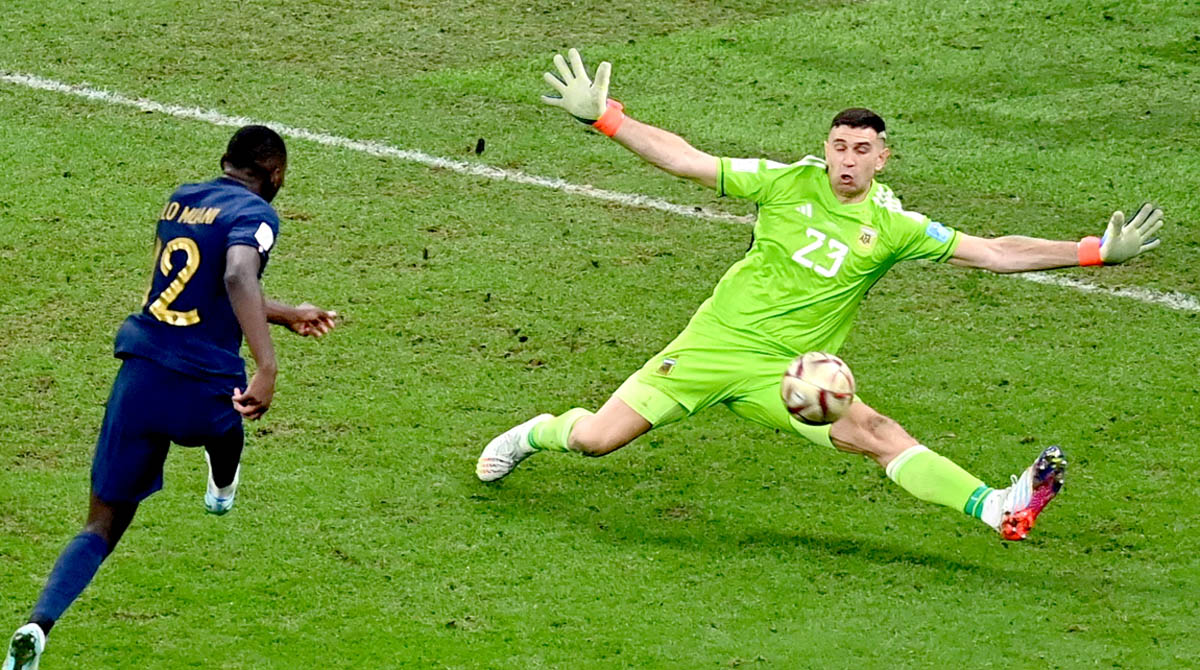

In [103]:
pd.DataFrame({
    'mejor fitness': results[10]['best_fit'],
    'mejor punto': results[10]['best_x'],
    'iteraciones': results[10]['best_iters']
}).sort_values(by='iteraciones').head(5)



,mejor fitness,mejor punto,iteraciones
37,[-304.2294826136889],[-512.0],1
10,[-304.2294826136889],[-512.0],1
24,[-304.2294826136889],[-512.0],2
36,[-304.2294826136889],[-512.0],3
49,[-304.2294826136889],[-512.0],4


In [104]:
best = min(
    (
        (fit, T_0, i, results[T_0]["best_x"][i])
        for T_0, data in results.items()
        for i, fit in enumerate(data["best_fit"])
    ),
    key=lambda x: x[0]
)

best_fit, best_T0, best_i, best_x = best

pd.DataFrame({
    'mejor fit': best_fit,
    'T0': best_T0,
    'iteraciones': best_i,
    'x': best_x
})

,mejor fit,T0,iteraciones,x
0,-418.982887,10,42,420.971004


In [105]:
for t in T_0s:
    datos = results[t]['best_fit']

    #int(datos)
    limite_superior = -415
    limite_inferior = -420

    contador = 0
    for arr in datos:
        valor = arr[0]  # Extraer el valor del array
        if limite_inferior <= valor <= limite_superior:
            contador += 1
    print(f"Valores en el intervalo [{limite_inferior}, {limite_superior}] (T0={t}): {contador}")


Valores en el intervalo [-420, -415] (T0=10): 7
Valores en el intervalo [-420, -415] (T0=50): 13
Valores en el intervalo [-420, -415] (T0=100): 11
Valores en el intervalo [-420, -415] (T0=500): 12
Valores en el intervalo [-420, -415] (T0=1000): 21


/var/folders/n0/_zbbdy_572bchcg3x3tncg0c0000gn/T/ipykernel_83766/2854315176.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box, labels=labels)


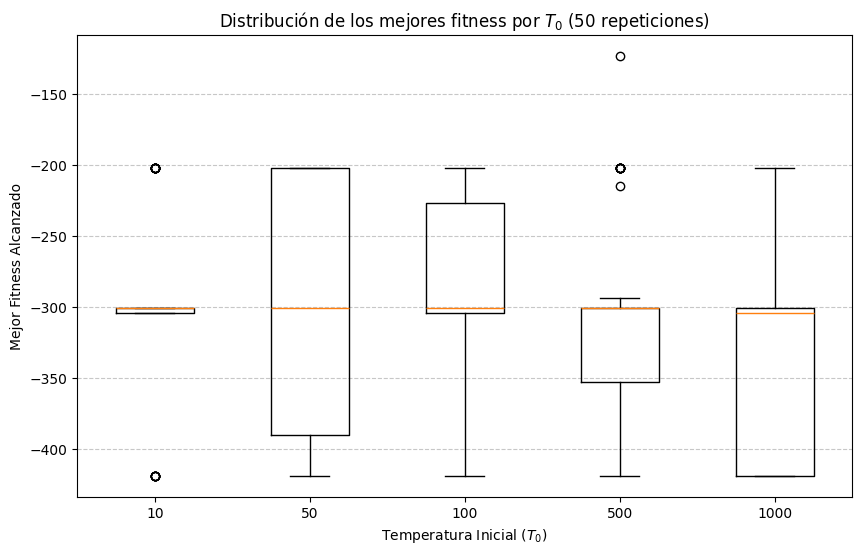

In [106]:
fig, ax = plt.subplots(figsize=(10, 6))

data_box = []
labels = []
for t0 in T_0s:
    fits = [f if np.isscalar(f) else f[0] for f in results[t0]['best_fit']]
    data_box.append(fits)
    labels.append(str(t0))

ax.boxplot(data_box, labels=labels)
ax.set_title(f'Distribución de los mejores fitness por $T_0$ ({n_exp} repeticiones)')
ax.set_xlabel('Temperatura Inicial ($T_0$)')
ax.set_ylabel('Mejor Fitness Alcanzado')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

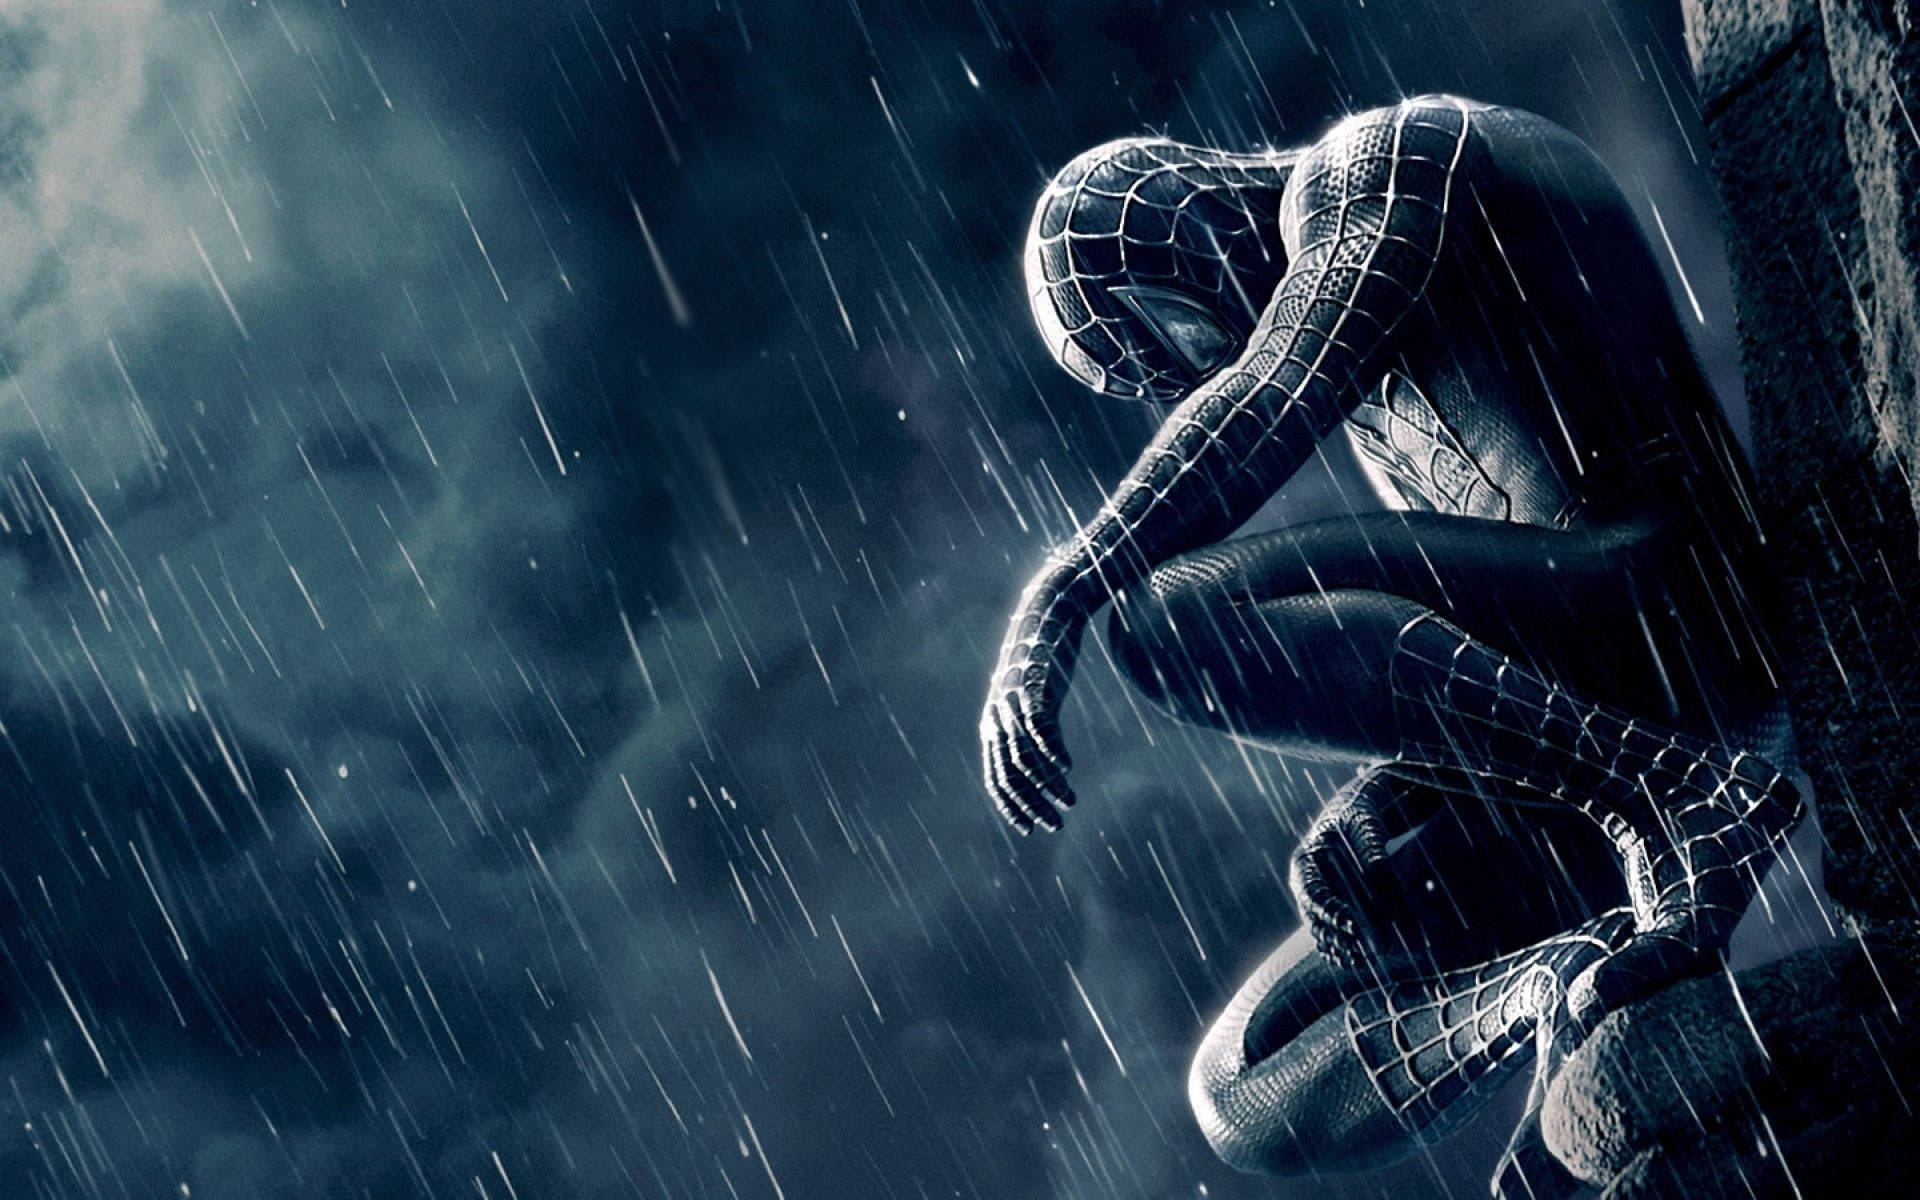

#### Experimento 2: Tasa de enfriamiento


Una vez identificado un valor apropiado de temperatura inicial en el Experimento 1, se procede a evaluar el impacto de la tasa de enfriamiento $\alpha$ sobre el rendimiento del algoritmo.

**Configuración experimental**:

$$
\begin{aligned}
\text{Función:} & \quad f_1(x), \quad x \in [-512, 512] \\
\text{Hiperparámetros:} & \quad T_0 = [T_{0,\text{óptimo}} \text{ del Exp.1}] \text{ (fijo)} \\
& \quad \alpha \in \{0.80, 0.85, 0.90, 0.95, 0.99\} \\
\text{Protocolo:} & \quad \text{Idéntico al Experimento 1}
\end{aligned}
$$



El parámetro $\alpha$ controla la velocidad del enfriamiento: valores cercanos a 1 producen enfriamiento lento que permite exploración prolongada pero requiere más iteraciones para converger, mientras que valores más pequeños producen enfriamiento rápido que favorece convergencia temprana pero con mayor riesgo de estancamiento en óptimos locales. Para el mismo número de iteraciones $N_{\text{max}} = 1000$, diferentes valores de $\alpha$ resultan en temperaturas finales muy diferentes:

- $\alpha = 0.80$: $T_{\text{final}} = T_0 \cdot 0.80^{1000} \approx 0$ (enfriamiento muy rápido)
- $\alpha = 0.95$: $T_{\text{final}} = T_0 \cdot 0.95^{1000} \approx 5.3 \times 10^{-23}$ (enfriamiento moderado)
- $\alpha = 0.99$: $T_{\text{final}} = T_0 \cdot 0.99^{1000} \approx 4.3 \times 10^{-5} T_0$ (enfriamiento lento)


> Aplicar el mismo protocolo de análisis que en el Experimento 1, generando tabla comparativa y visualizaciones. Adicionalmente, para cada valor de $\alpha$, calcular y comparar:
> - **Tasa de aceptación promedio**: proporción de movimientos que empeoran el fitness y son aceptados
> - **Iteración promedio del mejor hallazgo**: $\bar{t}_{\text{best}}$, indica cuándo típicamente se encuentra la mejor solución


In [107]:
T_0 = best_T0
alphas = [0.80,0.85,0.90,0.95,0.99]

In [108]:
results_exp2 = {}

for alpha in alphas:
    curr_dict = {} #diccionario auxiliar
    best_x_exp2=[]
    best_fit_exp2=[]
    best_iters_exp2 =[]
    worse_accepted_rate_exp2 = []
    for i in range(n_exp):
        start_point = np.array([np.random.uniform(lower, upper)]) #puntoa aleatorio
        sa_model = simulated_annealing(
            function=function, 
            start_point=start_point, 
            lower=[lower], 
            upper=[upper], 
            T_0=T_0, 
            alfa=alpha, 
            sigma=sigma, 
            cold_function=geometric_cooling, 
            n_max=N_max
        )
        best_point, f_best = sa_model.run()
        best_x_exp2.append(best_point)
        best_fit_exp2.append(f_best)
        best_iters_exp2.append(sa_model.t_best)
        worse_accepted_rate_exp2.append(sa_model.accepted['worse']/sa_model.accepted['total'])
        
    curr_dict['best_x'] = best_x_exp2
    curr_dict['best_fit'] = best_fit_exp2
    curr_dict['best_iters'] = best_iters_exp2
    curr_dict['best_accepted_rate'] = worse_accepted_rate_exp2
    results_exp2[alpha] = curr_dict 

In [109]:
df_fit_exp2 = results_to_df(results_exp2, "fit", alphas)
df_iters_exp2 = results_to_df(results_exp2, "iters", alphas)
df_x_exp2 = results_to_df(results_exp2, "x", alphas)
df_accepted_exp2 = results_to_df(results_exp2, "accepted_rate", alphas)

display(df_fit_exp2)
display(df_iters_exp2)
display(df_x_exp2)
df_accepted_exp2[['mean_accepted_rate']]

,median_fit,mean_fit,std_fit,min_fit,max_fit
0.80,-300.544531,-306.040964,78.425878,-418.982884,-201.840114
0.85,-300.544373,-313.149849,82.850562,-418.982874,-201.839096
0.90,-300.544287,-308.878436,85.458555,-418.982873,-201.836000
0.95,-302.387000,-318.034822,85.316401,-418.982887,-201.827192
0.99,-300.543637,-288.523585,75.454825,-418.982884,-201.830818


,median_iters,mean_iters,std_iters,min_iters,max_iters
0.80,491.5,514.32,305.449141,1,966
0.85,496.0,495.62,286.147856,1,998
0.90,507.5,545.98,311.316526,1,992
0.95,431.0,441.08,328.041146,1,998
0.99,609.0,513.84,320.288767,2,995


,median_x,mean_x,std_x,min_x,max_x
0.80,203.690526,-3.699928,343.316862,-512.0,421.967730
0.85,203.743749,39.699878,348.476616,-512.0,421.087801
0.90,203.832489,68.187169,330.768586,-512.0,421.489555
0.95,203.809378,60.262585,360.047389,-512.0,421.106981
0.99,203.685577,-12.680516,316.302500,-512.0,421.547231


,mean_accepted_rate
0.80,0.112771
0.85,0.158876
0.90,0.134063
0.95,0.287529
0.99,0.419613


In [110]:
best = min(
    (
        (fit, alpha, i, results_exp2[alpha]["best_x"][i])
        for alpha, data in results_exp2.items()
        for i, fit in enumerate(data["best_fit"])
    ),
    key=lambda x: x[0]
)

best_fit, best_alpha, best_i, best_x = best

pd.DataFrame({
    'mejor fit': best_fit,
    'alpha': best_alpha,
    'iteraciones': best_i,
    'x': best_x
})

,mejor fit,alpha,iteraciones,x
0,-418.982887,0.95,2,420.968667


**Preguntas de análisis**:

1. ¿Qué valor de $\alpha$ produce el mejor balance entre exploración y explotación para esta función?

2. ¿Existe correlación entre la tasa de aceptación y la calidad de las soluciones encontradas?

3. ¿El mejor $\alpha$ es el mismo si se mide por rendimiento promedio vs por mejor caso?

4. ¿Enfriamiento lento ($\alpha = 0.99$) siempre es mejor dado un número fijo de iteraciones?

5. ¿Cómo interactúa $\alpha$ con $T_0$? ¿La configuración óptima de uno depende del otro?


#### Experimento 3: Robustez ante inicialización



Los experimentos anteriores utilizan inicialización aleatoria uniforme en todo el dominio. Este experimento evalúa la robustez del algoritmo, con su configuración óptima identificada, ante diferentes estrategias de inicialización, particularmente inicialización en regiones lejanas del óptimo global.



**Configuración experimental**:

$$
\begin{aligned}
\text{Hiperparámetros:} & \quad T_0 = [T_{0,\text{óptimo}}], \quad \alpha = [\alpha_{\text{óptimo}}] \\
\text{Estrategias de inicialización:} & \\
& \quad \text{(a) Aleatoria uniforme en } [-512, 512] \text{ (baseline)} \\
& \quad \text{(b) Región cercana al origen: } [-50, 50] \\
& \quad \text{(c) Región lejana (negativa): } [-512, -200] \\
& \quad \text{(d) Región lejana (positiva, lado incorrecto): } [50, 250] \\
\text{Repeticiones:} & \quad 10 \text{ por cada estrategia}
\end{aligned}
$$


>Comparar las cuatro estrategias en términos de:
> - Capacidad de alcanzar el óptimo global ($x^* \approx 420.97$)
> - Variabilidad entre repeticiones
> - Número de iteraciones necesarias para convergencia


In [111]:
T_0 = best_T0
alpha = best_alpha

init_configs = [
    [-512,512],
    [-50,50],
    [-512,-200],
    [50,250]
]

In [127]:
results_exp3 = {}

for config in init_configs:
    curr_dict = {} #diccionario auxiliar
    best_x_exp3=[]
    best_fit_exp3=[]
    best_iters_exp3 =[]
    worse_accepted_rate_exp3 = []
    for i in range(n_exp):
        start_point = np.array([np.random.uniform(lower, upper)]) #puntoa aleatorio
        sa_model = simulated_annealing(
            function=function, 
            start_point=start_point, 
            lower=config[0], 
            upper=config[1], 
            T_0=T_0, 
            alfa=alpha, 
            sigma=sigma, 
            cold_function=geometric_cooling, 
            n_max=N_max
        )
        best_point, f_best = sa_model.run()
        best_x_exp3.append(best_point)
        best_fit_exp3.append(f_best)
        best_iters_exp3.append(sa_model.t_best)
        worse_accepted_rate_exp3.append(sa_model.accepted['worse']/sa_model.accepted['total'])
        
    curr_dict['best_x'] = best_x_exp3
    curr_dict['best_fit'] = best_fit_exp3
    curr_dict['best_iters'] = best_iters_exp3
    curr_dict['best_accepted_rate'] = worse_accepted_rate_exp3
    results_exp3[f"[{config[0]}-{config[1]}]"] = curr_dict 

In [128]:
indexes = ["[-512-512]","[-50-50]","[-512--200]","[50-250]"]

df_fit_exp3 = results_to_df(results_exp3, "fit", indexes)
df_iters_exp3 = results_to_df(results_exp3, "iters", indexes)
df_x_exp3 = results_to_df(results_exp3, "x", indexes)
df_accepted_exp3 = results_to_df(results_exp3, "accepted_rate", indexes)

display(df_fit_exp3)
display(df_iters_exp3)
display(df_x_exp3)
df_accepted_exp3[['mean_accepted_rate']]

,median_fit,mean_fit,std_fit,min_fit,max_fit
[-512-512],-300.544413,-296.246194,67.566803,-418.982851,-201.841205
[-50-50],-55.685256,-129.281111,112.989655,-418.126367,-22.405095
[-512--200],-300.544031,-257.220809,129.499496,-418.721104,119.262467
[50-250],-201.843005,-207.276577,63.387469,-414.117611,-51.932642


,median_iters,mean_iters,std_iters,min_iters,max_iters
[-512-512],619.5,553.04,303.509338,1,998
[-50-50],1.0,3.24,5.240458,1,27
[-512--200],174.0,259.62,278.778255,1,896
[50-250],368.0,397.62,347.272452,1,989


,median_x,mean_x,std_x,min_x,max_x
[-512-512],-302.475638,-90.386388,324.842361,-512.000000,421.050519
[-50-50],50.000000,4.555402,244.590891,-506.116471,477.962467
[-512--200],-302.463087,-144.920599,293.977959,-512.000000,493.349050
[50-250],203.806638,146.441423,202.330143,-503.376328,478.842948


,mean_accepted_rate
[-512-512],0.238395
[-50-50],0.476441
[-512--200],0.183073
[50-250],0.173277



**Preguntas**:

1. ¿La configuración óptima es robusta ante diferentes inicializaciones?
2. ¿Inicializar cerca del origen (región engañosa) perjudica significativamente el rendimiento?
3. ¿Qué proporción de ejecuciones logran escapar de sus cuencas iniciales y alcanzar el óptimo global?


### 1.3 Aplicación a función 2D: Oscilación Radial


#### Adaptaciones necesarias para 2D



**Operador de vecindario bidimensional**: La generación de vecinos en $\mathbb{R}^2$ se realiza mediante perturbación Gaussiana independiente en cada dimensión:

$$\begin{pmatrix} x' \\ y' \end{pmatrix} = \begin{pmatrix} x \\ y \end{pmatrix} + \begin{pmatrix} \delta_x \\ \delta_y \end{pmatrix}, \quad \delta_x, \delta_y \sim \mathcal{N}(0, \sigma^2)$$

donde $\sigma$ es la desviación estándar que controla el tamaño del paso de búsqueda. Un valor apropiado inicial para la función de Oscilación Radial con dominio $[-100, 100]^2$ es $\sigma = 10.0$, que representa aproximadamente el 10% del rango del dominio, permitiendo exploración efectiva sin pasos excesivamente grandes.

**Manejo de restricciones del dominio**: Cuando la perturbación genera un candidato $(x', y')$ que viola las restricciones del dominio, se debe aplicar una estrategia de corrección. Para este trabajo práctico se empleará la estrategia de **proyección al borde**: si $x' < -100$ se fija $x' = -100$, si $x' > 100$ se fija $x' = 100$, y análogamente para $y'$. Esto garantiza que todos los candidatos evaluados sean factibles sin desperdiciar evaluaciones.



#### Experimento 1: Calibración de temperatura inicial en 2D


El primer paso es determinar si la temperatura inicial $T_0$ óptima identificada en Schwefel 1D es apropiada para la función de Oscilación Radial, o si requiere ajuste debido a las diferencias en la escala y estructura del paisaje de fitness.



**Configuración experimental**:

$$
\begin{aligned}
\text{Función:} & \quad f_2(x,y) = (x^{2} + y^{2})^{0.25} \cdot [\sin^{2}(50 \cdot (x^{2} + y^{2})^{0.1}) + 1] \\
\text{Dominio:} & \quad (x,y) \in [-100, 100]^2 \\
\text{Hiperparámetros:} & \quad T_0 \in \{50, 100, 200, 500\} \\
& \quad \alpha = [\alpha_{\text{óptimo}} \text{ de Exp. 1.3.2}] \text{ (fijo)} \\
& \quad \sigma = 10.0 \text{ (desviación estándar de perturbación)} \\
\text{Iteraciones:} & \quad N_{\text{max}} = 2000 \\
\text{Repeticiones:} & \quad 10 \text{ ejecuciones independientes por cada } T_0 \\
\text{Inicialización:} & \quad (x_0, y_0) \text{ aleatorio uniforme en } [-100, 100]^2
\end{aligned}
$$



**Justificación de valores de $T_0$**: El rango de valores de $f_2$ en el dominio es significativamente diferente al de Schwefel 1D. Evaluaciones preliminares muestran que $f_2$ típicamente varía en el rango $[0, 100]$ aproximadamente, con incrementos $\Delta f$ que pueden ser del orden de 1-10 en pasos locales. Por lo tanto, se evalúan temperaturas desde 50 (conservador) hasta 500 (muy exploratorio).



**Métricas a registrar** (para cada una de las 10 repeticiones de cada configuración):

1. **Mejor fitness alcanzado**: $f_2(x_{\text{best}}, y_{\text{best}})$
2. **Posición de la mejor solución**: $(x_{\text{best}}, y_{\text{best}})$
3. **Distancia euclidiana al óptimo global**: $d = \sqrt{x_{\text{best}}^2 + y_{\text{best}}^2}$
4. **Iteración en que se encontró el mejor**: $t_{\text{best}}$
5. **Tasa de aceptación acumulada**: proporción de movimientos que empeoran y fueron aceptados


> Para cada valor de $T_0$, calcular sobre las 10 repeticiones:
> - Media aritmética de $f_{\text{best}}$
> - Mediana, mínimo y máximo de $f_{\text{best}}$
> - Desviación estándar
> - Media de la distancia al óptimo $\bar{d}$ 
> - Tiempo promedio de ejecución
> Presentar los resultados en una **tabla comparativa**:


| $T_0$ | Media | Mediana | Mín | Máx | Dist. promedio |
|-------|-------|---------|-----|-----|----------------|
| 50    | ...   | ...     | ... | ... | ...            |
| 100   | ...   | ...     | ... | ... | ...            |
| 200   | ...   | ...     | ... | ... | ...            |
| 500   | ...   | ...     | ... | ... | ...            |


> Adicionalmente, generar visualizaciones complementarias:
> 1. **Boxplot comparativo**: Un gráfico de boxplot que muestre, para cada valor de $T_0$, la distribución de los mejores fitness alcanzados.
> 2. **Scatter plot de posiciones finales**: Sobre un contour plot de la función, marcar las 10 posiciones finales $(x_{\text{best}}, y_{\text{best}})$ de cada configuración con diferentes colores. Incluir un círculo en el origen y círculos concéntricos a distancias 10, 25, 50 como referencia visual.
> 3. **Gráfico de convergencia promedio**: Para cada $T_0$, graficar la evolución del fitness promedio (promediado sobre las 10 repeticiones) vs iteración.

**Preguntas de análisis**:

1. ¿Qué valor de $T_0$ produce el mejor rendimiento promedio en términos de fitness alcanzado?
2. ¿La temperatura óptima en 2D coincide con la identificada en Schwefel 1D, o requiere ajuste?
3. ¿Cómo afecta $T_0$ a la distancia promedio al óptimo global? ¿Mayor temperatura facilita acercarse al origen?
4. ¿Existe una correlación entre la tasa de aceptación y la calidad de las soluciones finales?
5. ¿Cuántas de las 10 repeticiones de cada configuración logran encontrar soluciones dentro de un radio $d < 10$ del óptimo?


#### Experimento 2: Impacto de la desviación estándar del operador de vecindario


El parámetro $\sigma$ que controla el tamaño de los pasos en el operador de vecindario es crítico en problemas continuos. Pasos muy pequeños resultan en exploración local lenta, mientras que pasos muy grandes pueden generar movimientos erráticos que dificultan la convergencia fina hacia el óptimo.


**Configuración experimental**:

$$
\begin{aligned}
\text{Hiperparámetros:} & \quad T_0 = [T_{0,\text{óptimo}} \text{ del Exp. 1}] \text{ (fijo)} \\
& \quad \alpha = [\alpha_{\text{óptimo}}] \text{ (fijo)} \\
& \quad \sigma \in \{2.0, 5.0, 10.0, 20.0, 40.0\} \\
\text{Protocolo:} & \quad \text{Idéntico al Experimento 1}
\end{aligned}
$$

**Justificación del rango de $\sigma$**:
- $\sigma = 2.0$: pasos pequeños (~2% del rango del dominio), exploración local fina
- $\sigma = 10.0$: pasos moderados (~10% del rango), balance exploración-explotación
- $\sigma = 40.0$: pasos grandes (~40% del rango), exploración global amplia


> Aplicar el mismo protocolo estadístico del Experimento 1. Adicionalmente, para cada valor de $\sigma$, calcular:
> - **Número promedio de mejoras**: cuántas veces se actualiza $f_{\text{best}}$ a lo largo de las 2000 iteraciones
> - **Magnitud promedio de mejora**: cuando ocurre una mejora, cuál es el $|\Delta f|$ típico



**Preguntas de análisis**:

1. ¿Qué valor de $\sigma$ produce el mejor balance entre exploración global y refinamiento local?
2. ¿Pasos muy pequeños ($\sigma = 2.0$) resultan en estancamiento por exploración insuficiente del espacio?
3. ¿Pasos muy grandes ($\sigma = 40.0$) impiden convergencia fina al óptimo?
4. ¿Existe interacción entre $\sigma$ y $T_0$? ¿Temperaturas altas requieren pasos diferentes que temperaturas bajas?
5. Observando el gráfico de contorno con las trayectorias típicas, ¿cómo difiere el patrón de búsqueda para $\sigma$ pequeño vs grande?


#### Análisis integrador

Una vez completados los tres experimentos, se debe realizar una síntesis que responda:

1. **Transferencia de hiperparámetros**: ¿Los valores óptimos de $T_0$ y $\alpha$ identificados en Schwefel 1D transfieren efectivamente a Oscilación Radial 2D, o requieren ajuste sustancial?

2. **Rol del operador de vecindario**: ¿El parámetro $\sigma$ tiene un impacto comparable o mayor que $T_0$ y $\alpha$ en el rendimiento 2D?

3. **Desafíos de dimensionalidad**: ¿La función 2D presenta desafíos cualitativamente diferentes a la 1D que afectan el comportamiento de SA? Por ejemplo, ¿la convergencia es más lenta? ¿La variabilidad entre repeticiones es mayor?

4. **Visualización del comportamiento**: Basándose en las visualizaciones en tiempo real ejecutadas durante los experimentos, describir cualitativamente cómo SA navega el paisaje radial con oscilaciones. ¿Sigue una trayectoria predominantemente radial hacia el origen, o exhibe movimientos más erráticos? ¿A qué se debe?

---